
# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 03 — Signal Diagnostics

**Purpose:** test whether SuperbCommand states contain economically meaningful information about subsequent returns **before** any strategy optimisation or portfolio construction.

This notebook is deliberately diagnostic rather than prescriptive.

It asks:

- Do SuperbCommand bullish / bearish states correspond to different future returns?
- Do Early Reversal, Pullback and Profit-Taking states have distinct forward-return profiles?
- Are results consistent across markets and asset classes?
- Does the signal appear to generalise beyond the original equity-sector context?
- Are results driven by one or two exceptional markets?
- Does the indicator create sufficiently persistent states to be useful at weekly frequency?

### Research discipline

No hyperparameters are optimised here.

The 2026 holdout remains locked.

The objective is to understand the information content of the current, fixed SuperbCommand specification.


In [1]:

# ============================================================
# 3.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
import sys
import platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 03 cannot run with the holdout unlocked.")

SIGNAL_PATH = PATHS["data_processed"] / "superbcommand_weekly_signal_panel.parquet"
META_PATH = PATHS["data_processed"] / "prototype_universe_metadata.csv"

if not SIGNAL_PATH.exists():
    raise FileNotFoundError("Run Notebook 02 first.")
if not META_PATH.exists():
    raise FileNotFoundError("Run Notebook 01 first.")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:

# ============================================================
# 3.2 — LOAD SIGNAL PANEL & METADATA
# ============================================================
panel = pd.read_parquet(SIGNAL_PATH)
meta = pd.read_csv(META_PATH, index_col=0)

# Normalise MultiIndex ordering.
if panel.index.names != ["date", "ticker"]:
    try:
        panel = panel.reorder_levels(["date", "ticker"]).sort_index()
    except Exception:
        panel = panel.sort_index()

dates = panel.index.get_level_values("date")
if dates.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected in signal panel.")

print("Rows:", len(panel))
print("Markets:", panel.index.get_level_values("ticker").nunique())
print("Dates:", dates.min().date(), "→", dates.max().date())


Rows: 11370
Markets: 11
Dates: 2005-01-07 → 2025-12-26



## Forward-return horizons

Signal diagnostics will examine subsequent simple returns over:

- 1 week;
- 2 weeks;
- 4 weeks;
- 8 weeks;
- 13 weeks;
- 26 weeks;
- 52 weeks.

These are fixed research horizons, not optimised parameters.


In [3]:

# ============================================================
# 3.3 — CONSTRUCT FORWARD RETURNS
# ============================================================
HORIZONS = [1, 2, 4, 8, 13, 26, 52]

def add_forward_returns(df):
    out = df.copy()
    c = out["close"]
    for h in HORIZONS:
        out[f"fwd_{h}w"] = c.shift(-h) / c - 1.0
    return out

parts = []
for ticker, g in panel.groupby(level="ticker", sort=False):
    x = g.droplevel("ticker").copy()
    x = add_forward_returns(x)
    x["ticker"] = ticker
    parts.append(x.reset_index())

diag = pd.concat(parts, ignore_index=True)
diag["asset_class"] = diag["ticker"].map(meta["asset_class"])
diag["market_name"] = diag["ticker"].map(meta["market_name"])

print("Diagnostic rows:", len(diag))
display(diag.head())


Diagnostic rows: 11370


,date,open,high,low,close,smoothed_price,fast_ma,slow_ma,oscillator,signal_line,...,fwd_1w,fwd_2w,fwd_4w,fwd_8w,fwd_13w,fwd_26w,fwd_52w,ticker,asset_class,market_name
0,2005-01-07,14.628803,14.683198,13.789661,13.886844,4.516141,NaN,NaN,NaN,NaN,...,0.025487,0.010602,0.076409,0.151094,0.087899,0.140492,0.501771,EEM,equities,Emerging-Market Equities
1,2005-01-14,13.968800,14.240783,13.853484,14.240783,11.490109,NaN,NaN,NaN,NaN,...,-0.014515,0.009269,0.066972,0.097937,-0.005348,0.142093,0.459194,EEM,equities,Emerging-Market Equities
2,2005-01-21,14.232808,14.286471,13.845507,14.034078,14.391727,NaN,NaN,NaN,NaN,...,0.024134,0.065116,0.101241,0.083462,0.031524,0.178604,0.456387,EEM,equities,Emerging-Market Equities
3,2005-01-28,14.205964,14.407593,13.998537,14.372780,14.760104,NaN,NaN,NaN,NaN,...,0.040016,0.057173,0.113135,0.009285,0.010597,0.167180,0.539781,EEM,equities,Emerging-Market Equities
4,2005-02-04,14.505506,14.969683,14.502605,14.947926,14.757540,NaN,NaN,NaN,NaN,...,0.016497,0.033916,0.069384,-0.010189,0.011888,0.126637,0.424753,EEM,equities,Emerging-Market Equities



## State taxonomy

For diagnostics, the Pine state machine is mapped into economically interpretable labels:

- **EARLY_REVERSAL**
- **PULLBACK**
- **PROFIT_TAKING**
- **STANDBY**
- **HELD_NEUTRAL**
- **OUT**

This is descriptive only. It does not yet imply any capital allocation.


In [4]:

# ============================================================
# 3.4 — LABEL STRATEGIC STATES
# ============================================================
def state_label(row):
    if bool(row["standby_active"]):
        return "STANDBY"
    if bool(row["early_reversal_active"]):
        return "EARLY_REVERSAL"
    if bool(row["pullback_active"]):
        return "PULLBACK"
    if bool(row["profit_taking_active"]):
        return "PROFIT_TAKING"
    if bool(row["position_held"]):
        return "HELD_NEUTRAL"
    return "OUT"

diag["state"] = diag.apply(state_label, axis=1)

state_counts = (
    diag.groupby(["asset_class", "state"])
    .size()
    .rename("observations")
    .reset_index()
)

display(state_counts)


,asset_class,state,observations
0,commodities,EARLY_REVERSAL,442
1,commodities,HELD_NEUTRAL,571
2,commodities,OUT,572
3,commodities,PROFIT_TAKING,139
4,commodities,PULLBACK,280
5,commodities,STANDBY,129
6,crypto,EARLY_REVERSAL,67
7,crypto,HELD_NEUTRAL,179
8,crypto,OUT,194
9,crypto,PROFIT_TAKING,28



## 3.5 Event-level forward returns

The first test looks at the actual one-shot events generated by the state machine:

- strategic entry;
- strategic exit;
- Early Reversal start;
- Pullback start;
- Profit-Taking start;
- Standby anchor.

This avoids mixing the *event itself* with all subsequent weeks spent inside the same state.


In [5]:

# ============================================================
# 3.5 — EVENT-LEVEL FORWARD RETURN SUMMARY
# ============================================================
EVENTS = {
    "Strategic Entry": "position_entry_event",
    "Strategic Exit": "position_exit_event",
    "Early Reversal Start": "start_early_reversal",
    "Pullback Start": "start_pullback",
    "Profit-Taking Start": "start_profit_taking",
    "Standby Anchor": "standby_anchor_event",
}

rows = []
for event_name, col in EVENTS.items():
    e = diag[diag[col] == True]
    for h in HORIZONS:
        r = e[f"fwd_{h}w"].dropna()
        rows.append({
            "event": event_name,
            "horizon_weeks": h,
            "n": len(r),
            "mean_return": r.mean(),
            "median_return": r.median(),
            "hit_rate_positive": (r > 0).mean() if len(r) else np.nan,
            "std_return": r.std(),
        })

event_summary = pd.DataFrame(rows)
display(event_summary)


,event,horizon_weeks,n,mean_return,median_return,hit_rate_positive,std_return
0,Strategic Entry,1,69,-0.002142,-0.000467,0.463768,0.018698
1,Strategic Entry,2,69,0.002839,0.004267,0.637681,0.022625
2,Strategic Entry,4,69,0.009122,0.007015,0.623188,0.033803
3,Strategic Entry,8,68,0.020424,0.008014,0.632353,0.094531
4,Strategic Entry,13,68,0.031802,0.011539,0.647059,0.158569
5,Strategic Entry,26,68,0.054396,0.023113,0.676471,0.235089
6,Strategic Entry,52,67,0.191009,0.036025,0.597015,1.149553
7,Strategic Exit,1,58,0.001777,0.000403,0.517241,0.020025
8,Strategic Exit,2,58,0.003251,0.002173,0.586207,0.036611
9,Strategic Exit,4,58,-0.000453,-0.003210,0.362069,0.050634



## 3.6 State-conditional forward returns

This section asks whether being in a given SuperbCommand state is associated with different subsequent return distributions.

Because consecutive weekly observations inside a state overlap, these results are **descriptive rather than inferential**. They should not be interpreted as independent observations.


In [6]:

# ============================================================
# 3.6 — STATE-CONDITIONAL FORWARD RETURNS
# ============================================================
rows = []

for state, s in diag.groupby("state"):
    for h in HORIZONS:
        r = s[f"fwd_{h}w"].dropna()
        rows.append({
            "state": state,
            "horizon_weeks": h,
            "n": len(r),
            "mean_return": r.mean(),
            "median_return": r.median(),
            "hit_rate_positive": (r > 0).mean() if len(r) else np.nan,
            "std_return": r.std(),
        })

state_summary = pd.DataFrame(rows)
display(state_summary)


,state,horizon_weeks,n,mean_return,median_return,hit_rate_positive,std_return
0,EARLY_REVERSAL,1,1947,0.001868,0.000710,0.530046,0.023416
1,EARLY_REVERSAL,2,1946,0.003978,0.002075,0.558582,0.034551
2,EARLY_REVERSAL,4,1944,0.007842,0.003491,0.579733,0.050652
3,EARLY_REVERSAL,8,1939,0.015302,0.008531,0.614750,0.082921
4,EARLY_REVERSAL,13,1934,0.025224,0.012722,0.632885,0.126822
5,EARLY_REVERSAL,26,1921,0.054428,0.022775,0.668402,0.270160
6,EARLY_REVERSAL,52,1915,0.182411,0.046903,0.686684,1.255420
7,HELD_NEUTRAL,1,3568,0.002692,0.001029,0.561939,0.030872
8,HELD_NEUTRAL,2,3564,0.005353,0.002016,0.578002,0.048106
9,HELD_NEUTRAL,4,3556,0.010415,0.003492,0.592520,0.077344


horizon_weeks,1,2,4,8,13,26,52
state,,,,,,,
EARLY_REVERSAL,0.19%,0.40%,0.78%,1.53%,2.52%,5.44%,18.24%
HELD_NEUTRAL,0.27%,0.54%,1.04%,2.08%,3.45%,7.23%,11.01%
OUT,0.14%,0.27%,0.58%,1.37%,2.55%,6.54%,17.35%
PROFIT_TAKING,0.07%,0.13%,0.41%,1.03%,2.04%,5.59%,7.02%
PULLBACK,0.10%,0.22%,0.49%,0.98%,1.75%,2.60%,7.02%
STANDBY,0.11%,0.24%,0.47%,0.62%,0.30%,0.33%,9.57%


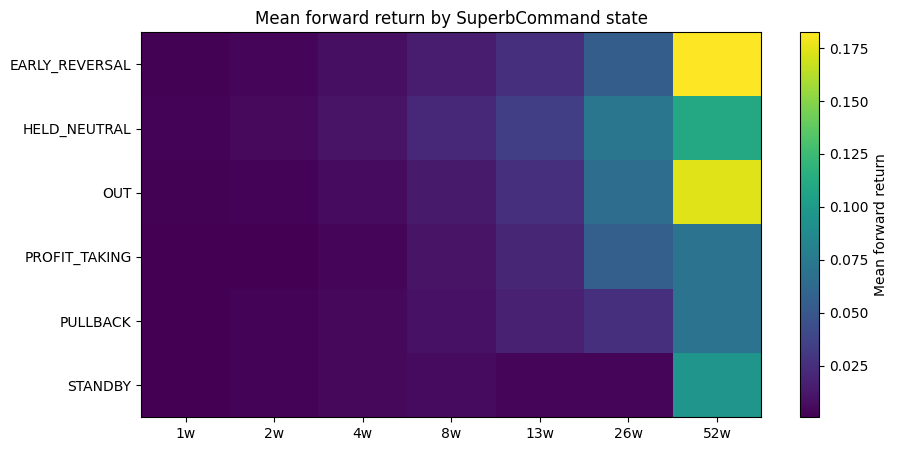

In [7]:

# ============================================================
# 3.7 — HEATMAP-LIKE TABLE OF MEAN FORWARD RETURNS
# ============================================================
mean_table = state_summary.pivot(
    index="state",
    columns="horizon_weeks",
    values="mean_return"
).sort_index()

display(mean_table.style.format("{:.2%}"))

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mean_table.values, aspect="auto")
ax.set_xticks(range(len(mean_table.columns)))
ax.set_xticklabels([f"{h}w" for h in mean_table.columns])
ax.set_yticks(range(len(mean_table.index)))
ax.set_yticklabels(mean_table.index)
ax.set_title("Mean forward return by SuperbCommand state")
plt.colorbar(im, ax=ax, label="Mean forward return")
plt.show()



## 3.8 Market-level consistency

A robust cross-asset signal should not depend entirely on aggregate pooling.

This section therefore examines the same forward-return relationships by individual market.


In [8]:

# ============================================================
# 3.8 — MARKET-LEVEL EVENT CONSISTENCY
# ============================================================
PRIMARY_EVENT = "start_early_reversal"
PRIMARY_HORIZON = 13

market_rows = []

for ticker, s in diag.groupby("ticker"):
    e = s[s[PRIMARY_EVENT] == True]
    r = e[f"fwd_{PRIMARY_HORIZON}w"].dropna()

    market_rows.append({
        "ticker": ticker,
        "asset_class": meta.loc[ticker, "asset_class"],
        "market_name": meta.loc[ticker, "market_name"],
        "events": len(r),
        "mean_fwd_return": r.mean() if len(r) else np.nan,
        "median_fwd_return": r.median() if len(r) else np.nan,
        "positive_hit_rate": (r > 0).mean() if len(r) else np.nan,
    })

market_consistency = pd.DataFrame(market_rows).set_index("ticker")
display(market_consistency)


,asset_class,market_name,events,mean_fwd_return,median_fwd_return,positive_hit_rate
ticker,,,,,,
BTC-USD,crypto,Bitcoin,3,0.510575,0.392005,0.666667
DBC,commodities,Broad Commodities,8,-0.034653,-0.037034,0.250000
EEM,equities,Emerging-Market Equities,6,0.024081,0.005762,0.500000
EFA,equities,Developed ex-US Equities,7,0.040642,0.029096,0.714286
GLD,commodities,Gold,7,-0.005234,-0.034432,0.428571
IEF,rates,US Treasury 7-10Y,8,-0.005696,-0.001717,0.500000
SHY,rates,US Treasury 1-3Y,11,0.006486,0.003576,0.909091
SPY,equities,US Large-Cap Equities,8,0.034721,0.053186,0.625000
TIP,rates,US Inflation-Linked Treasuries,8,0.021915,0.023114,0.875000


In [9]:

# ============================================================
# 3.9 — ASSET-CLASS CONSISTENCY
# ============================================================
asset_rows = []

for asset_class, s in diag.groupby("asset_class"):
    for event_name, col in EVENTS.items():
        e = s[s[col] == True]
        for h in [4, 13, 26]:
            r = e[f"fwd_{h}w"].dropna()
            asset_rows.append({
                "asset_class": asset_class,
                "event": event_name,
                "horizon_weeks": h,
                "n": len(r),
                "mean_return": r.mean() if len(r) else np.nan,
                "median_return": r.median() if len(r) else np.nan,
                "hit_rate_positive": (r > 0).mean() if len(r) else np.nan,
            })

asset_event_summary = pd.DataFrame(asset_rows)
display(asset_event_summary)


,asset_class,event,horizon_weeks,n,mean_return,median_return,hit_rate_positive
0,commodities,Strategic Entry,4,15,0.005318,0.003216,0.533333
1,commodities,Strategic Entry,13,15,-0.020924,-0.034432,0.333333
2,commodities,Strategic Entry,26,15,-0.018274,-0.039084,0.466667
3,commodities,Strategic Exit,4,13,-0.003687,-0.014667,0.384615
4,commodities,Strategic Exit,13,13,0.014545,0.014103,0.692308
...,...,...,...,...,...,...,...
85,rates,Profit-Taking Start,13,71,-0.001563,0.001837,0.605634
86,rates,Profit-Taking Start,26,71,0.015464,0.005511,0.676056
87,rates,Standby Anchor,4,28,-0.007141,-0.002331,0.392857
88,rates,Standby Anchor,13,28,-0.009643,-0.000407,0.464286



## 3.10 Directional information test

A simple diagnostic is whether SuperbCommand's strategic position state separates future returns:

\[
E[r_{t+h}\mid Held]
\]

versus

\[
E[r_{t+h}\mid Out].
\]

This is not a backtest because no transaction costs, sizing, or execution assumptions are applied.


In [10]:

# ============================================================
# 3.10 — HELD VS OUT FORWARD RETURNS
# ============================================================
rows = []

for held_value, label in [(True, "HELD"), (False, "OUT")]:
    s = diag[diag["position_held"] == held_value]
    for h in HORIZONS:
        r = s[f"fwd_{h}w"].dropna()
        rows.append({
            "position_state": label,
            "horizon_weeks": h,
            "n": len(r),
            "mean_return": r.mean(),
            "median_return": r.median(),
            "hit_rate_positive": (r > 0).mean() if len(r) else np.nan,
        })

held_out_summary = pd.DataFrame(rows)
display(held_out_summary)

pivot = held_out_summary.pivot(
    index="horizon_weeks",
    columns="position_state",
    values="mean_return"
)
pivot["HELD_minus_OUT"] = pivot["HELD"] - pivot["OUT"]
display(pivot.style.format("{:.2%}"))


,position_state,horizon_weeks,n,mean_return,median_return,hit_rate_positive
0,HELD,1,8441,0.001899,0.000919,0.552423
1,HELD,2,8430,0.003871,0.001673,0.566667
2,HELD,4,8408,0.007818,0.003178,0.582422
3,HELD,8,8366,0.015505,0.006541,0.607817
4,HELD,13,8316,0.025602,0.010940,0.631193
5,HELD,26,8175,0.052879,0.020857,0.650275
6,HELD,52,7891,0.115692,0.037472,0.663794
7,OUT,1,2918,0.001441,0.001199,0.545236
8,OUT,2,2918,0.002729,0.002517,0.569911
9,OUT,4,2918,0.005815,0.003937,0.575394


position_state,HELD,OUT,HELD_minus_OUT
horizon_weeks,,,
1,0.19%,0.14%,0.05%
2,0.39%,0.27%,0.11%
4,0.78%,0.58%,0.20%
8,1.55%,1.37%,0.18%
13,2.56%,2.55%,0.01%
26,5.29%,6.54%,-1.25%
52,11.57%,17.35%,-5.78%



## 3.11 Regime-duration diagnostics

Trend-following systems need sufficiently persistent regimes to overcome trading costs and noise.

The following analysis measures contiguous runs of the strategic position and zone states.


In [11]:

# ============================================================
# 3.11 — STATE DURATION ANALYSIS
# ============================================================
def run_lengths(series):
    """
    Return contiguous state runs with a clean RangeIndex.

    Explicitly resetting the index avoids a pandas ambiguity where the
    input Series name ("state") can also become the groupby-result index
    name, leaving "state" as both an index level and a column label.
    """
    s = series.astype(str).copy()
    grp = (s != s.shift()).cumsum()

    runs = pd.DataFrame({
        "state": s.groupby(grp).first().to_numpy(),
        "length": s.groupby(grp).size().to_numpy(),
    }).reset_index(drop=True)

    return runs

duration_rows = []

for ticker, s in diag.sort_values(["ticker", "date"]).groupby("ticker"):
    runs = run_lengths(s["state"])
    for state, g in runs.groupby("state"):
        duration_rows.append({
            "ticker": ticker,
            "asset_class": meta.loc[ticker, "asset_class"],
            "state": state,
            "runs": len(g),
            "mean_weeks": g["length"].mean(),
            "median_weeks": g["length"].median(),
            "max_weeks": g["length"].max(),
        })

duration_summary = pd.DataFrame(duration_rows)
display(duration_summary)


,ticker,asset_class,state,runs,mean_weeks,median_weeks,max_weeks
0,BTC-USD,crypto,EARLY_REVERSAL,3,22.333333,19.0,32
1,BTC-USD,crypto,HELD_NEUTRAL,12,14.916667,11.5,42
2,BTC-USD,crypto,OUT,3,64.666667,52.0,113
3,BTC-USD,crypto,PROFIT_TAKING,8,3.500000,3.5,6
4,BTC-USD,crypto,PULLBACK,9,10.222222,10.0,20
...,...,...,...,...,...,...,...
61,UUP,fx,HELD_NEUTRAL,27,11.555556,7.0,49
62,UUP,fx,OUT,7,43.857143,27.0,160
63,UUP,fx,PROFIT_TAKING,18,3.000000,2.0,8
64,UUP,fx,PULLBACK,15,7.733333,7.0,20



## 3.12 Simple non-parametric bootstrap confidence intervals

To avoid imposing normality, Notebook 03 uses a simple bootstrap on **event-level** forward returns.

This is intentionally limited to event-level samples because weekly state observations overlap heavily.

These intervals are still descriptive and should not be treated as definitive statistical proof.


In [12]:

# ============================================================
# 3.12 — BOOTSTRAP EVENT MEAN CONFIDENCE INTERVALS
# ============================================================
RNG = np.random.default_rng(CFG["reproducibility"]["global_random_seed"])
BOOTSTRAPS = 2000

def bootstrap_mean_ci(x, n_boot=BOOTSTRAPS, alpha=0.05):
    x = pd.Series(x).dropna().to_numpy(float)
    if len(x) < 5:
        return np.nan, np.nan, np.nan
    means = np.empty(n_boot)
    for i in range(n_boot):
        means[i] = RNG.choice(x, size=len(x), replace=True).mean()
    return (
        x.mean(),
        np.quantile(means, alpha / 2),
        np.quantile(means, 1 - alpha / 2),
    )

boot_rows = []

for event_name, col in EVENTS.items():
    e = diag[diag[col] == True]
    for h in [4, 13, 26]:
        mean_, lo, hi = bootstrap_mean_ci(e[f"fwd_{h}w"])
        boot_rows.append({
            "event": event_name,
            "horizon_weeks": h,
            "n": e[f"fwd_{h}w"].notna().sum(),
            "mean_return": mean_,
            "ci_2_5": lo,
            "ci_97_5": hi,
        })

bootstrap_summary = pd.DataFrame(boot_rows)
display(bootstrap_summary)


,event,horizon_weeks,n,mean_return,ci_2_5,ci_97_5
0,Strategic Entry,4,69,0.009122,0.001583,0.017717
1,Strategic Entry,13,68,0.031802,0.002659,0.078526
2,Strategic Entry,26,68,0.054396,0.007161,0.116183
3,Strategic Exit,4,58,-0.000453,-0.013260,0.013235
4,Strategic Exit,13,58,-0.020790,-0.057567,0.008989
5,Strategic Exit,26,57,-0.015543,-0.053353,0.017000
6,Early Reversal Start,4,81,0.008263,0.001501,0.015165
7,Early Reversal Start,13,80,0.028545,0.002895,0.062283
8,Early Reversal Start,26,80,0.047517,0.005805,0.099599
9,Pullback Start,4,213,0.005597,-0.001947,0.013120



## 3.13 Concentration test

A cross-asset signal is less credible if nearly all apparent value comes from a single market.

For the primary Early Reversal diagnostic, Notebook 03 therefore compares pooled results with leave-one-market-out results.


In [14]:

# ============================================================
# 3.13 — LEAVE-ONE-MARKET-OUT DIAGNOSTIC
# ============================================================
event_col = "start_early_reversal"
h = 13

base = diag[diag[event_col] == True][f"fwd_{h}w"].dropna().mean()

loo_rows = []
for ticker in sorted(diag["ticker"].unique()):
    x = diag[(diag["ticker"] != ticker) & (diag[event_col] == True)][f"fwd_{h}w"].dropna()
    loo_rows.append({
        "excluded_market": ticker,
        "remaining_events": len(x),
        "mean_return": x.mean() if len(x) else np.nan,
        "difference_vs_full": (x.mean() - base) if len(x) else np.nan,
    })

loo = pd.DataFrame(loo_rows).set_index("excluded_market")
print("Full-sample Early Reversal 13-week mean:", f"{base:.2%}")
display(loo)


Full-sample Early Reversal 13-week mean: 2.85%


,remaining_events,mean_return,difference_vs_full
excluded_market,,,
BTC-USD,77,0.009765,-0.018780
DBC,72,0.035567,0.007022
EEM,74,0.028907,0.000362
EFA,73,0.027386,-0.001160
GLD,73,0.031785,0.003239
IEF,72,0.032350,0.003805
SHY,69,0.032062,0.003517
SPY,72,0.027859,-0.000686
TIP,72,0.029282,0.000737



## 3.14 Diagnostic charts by market

These charts allow direct inspection of forward outcomes around SuperbCommand events.

They are especially useful for detecting logic that appears statistically attractive but behaves oddly in individual markets.


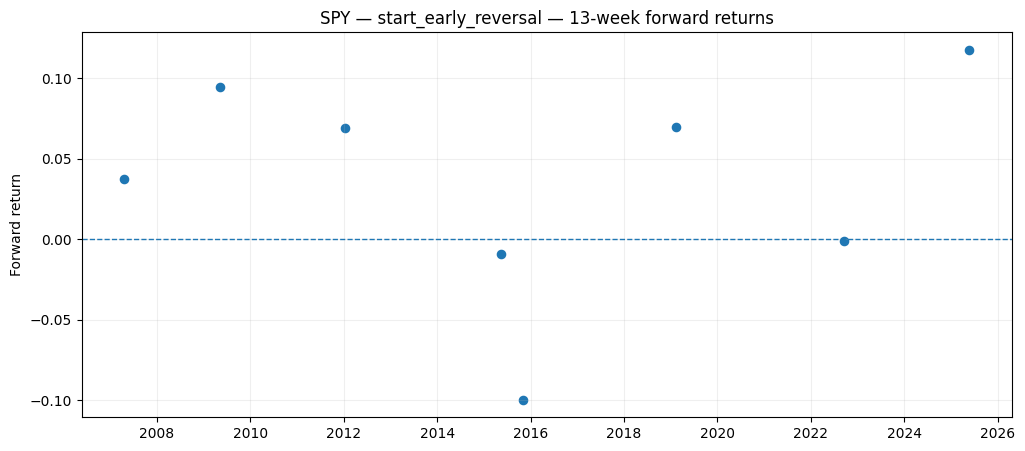

In [15]:

# ============================================================
# 3.14 — SELECTED MARKET FORWARD-RETURN SCATTER
# ============================================================
PLOT_TICKER = "SPY"
PLOT_EVENT = "start_early_reversal"
PLOT_HORIZON = 13

x = diag[(diag["ticker"] == PLOT_TICKER) & (diag[PLOT_EVENT] == True)].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(x["date"], x[f"fwd_{PLOT_HORIZON}w"], s=35)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(
    f"{PLOT_TICKER} — {PLOT_EVENT} — {PLOT_HORIZON}-week forward returns"
)
ax.set_ylabel("Forward return")
ax.grid(alpha=0.2)
plt.show()



## 3.15 Save diagnostics

The outputs from this notebook become the evidence base for deciding whether to proceed to strategy implementation and ablation.

No parameter or architecture choice should be changed solely because of one attractive table here.


In [16]:

# ============================================================
# 3.15 — SAVE OUTPUTS
# ============================================================
OUT_DIR = PATHS["results"]

paths = {
    "event_summary": OUT_DIR / "03_event_forward_returns.csv",
    "state_summary": OUT_DIR / "03_state_forward_returns.csv",
    "market_consistency": OUT_DIR / "03_market_consistency.csv",
    "asset_event_summary": OUT_DIR / "03_asset_class_event_summary.csv",
    "held_out_summary": OUT_DIR / "03_held_vs_out.csv",
    "duration_summary": OUT_DIR / "03_state_durations.csv",
    "bootstrap_summary": OUT_DIR / "03_bootstrap_event_ci.csv",
    "leave_one_out": OUT_DIR / "03_leave_one_market_out.csv",
}

event_summary.to_csv(paths["event_summary"], index=False)
state_summary.to_csv(paths["state_summary"], index=False)
market_consistency.to_csv(paths["market_consistency"])
asset_event_summary.to_csv(paths["asset_event_summary"], index=False)
held_out_summary.to_csv(paths["held_out_summary"], index=False)
duration_summary.to_csv(paths["duration_summary"], index=False)
bootstrap_summary.to_csv(paths["bootstrap_summary"], index=False)
loo.to_csv(paths["leave_one_out"])

for k, p in paths.items():
    print(f"{k:24s} -> {p}")


event_summary            -> /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/03_event_forward_returns.csv
state_summary            -> /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/03_state_forward_returns.csv
market_consistency       -> /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/03_market_consistency.csv
asset_event_summary      -> /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/03_asset_class_event_summary.csv
held_out_summary         -> /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/03_held_vs_out.csv
duration_summary         -> /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/03_state_durations.csv
bootstrap_summary        -> /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/03_bootstrap_event_ci.csv
leave_one_out    


## 3.16 Validation suite

Notebook 03 passes only if:

- the holdout remains absent;
- all expected markets are present;
- forward returns are available;
- state labels are valid;
- the diagnostic outputs were written successfully.


In [17]:

# ============================================================
# 3.16 — VALIDATION SUITE
# ============================================================
expected_states = {
    "EARLY_REVERSAL",
    "PULLBACK",
    "PROFIT_TAKING",
    "STANDBY",
    "HELD_NEUTRAL",
    "OUT",
}

checks = {}
checks["diagnostic_table_nonempty"] = len(diag) > 0
checks["holdout_absent"] = pd.to_datetime(diag["date"]).max() <= RESEARCH_END
checks["all_markets_present"] = set(diag["ticker"].unique()) == set(meta.index)
checks["forward_returns_created"] = all(f"fwd_{h}w" in diag.columns for h in HORIZONS)
checks["states_valid"] = set(diag["state"].unique()).issubset(expected_states)
checks["early_reversal_events_exist"] = int(diag["start_early_reversal"].sum()) > 0
checks["output_files_written"] = all(p.exists() for p in paths.values())

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 03 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 03 STATUS: PASS")
print("=" * 78)
print("Signal diagnostics completed.")
print("No hyperparameters were optimised.")
print("2026 holdout: NOT ACCESSED")
print("Proceed to Notebook 04 — Strategy Engine.")


                      check  passed
  diagnostic_table_nonempty    True
             holdout_absent    True
        all_markets_present    True
    forward_returns_created    True
               states_valid    True
early_reversal_events_exist    True
       output_files_written    True

NOTEBOOK 03 STATUS: PASS
Signal diagnostics completed.
No hyperparameters were optimised.
2026 holdout: NOT ACCESSED
Proceed to Notebook 04 — Strategy Engine.


In [18]:

# ============================================================
# 3.17 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "03",
    "notebook_name": "Signal Diagnostics",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_accessed": False,
    "forward_return_horizons_weeks": HORIZONS,
    "markets": sorted(diag["ticker"].unique().tolist()),
    "states": sorted(diag["state"].unique().tolist()),
    "outputs": {k: str(v) for k, v in paths.items()},
    "status": "PASS",
}

manifest_path = PATHS["manifests"] / "03_signal_diagnostics_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(manifest_path)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/03_signal_diagnostics_manifest.json



---

# End of Notebook 03

## What this notebook establishes

Notebook 03 does not ask whether a finished SuperbCommand portfolio makes money.

It asks the more fundamental question:

> **Do the fixed SuperbCommand states contain useful information about what happens next?**

If the answer is broadly yes across markets and asset classes, the next step is justified.

## Next notebook

**Notebook 04 — Strategy Engine**

Notebook 04 should translate the existing indicator states into explicit exposure rules while keeping the first implementation deliberately simple.

That notebook will establish the baseline long/cash and long/short trading mechanics before any parameter optimisation.
